### **Plotting the fitted models for Bias and Variance**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Generate reproducible non linear data
np.random.seed(42)

In [2]:
X = np.linspace(0,10,40).reshape(-1,1)

# np.random.normal(0,5,40)is to generate random noise
# and add realistic variation to the output data.
# np.random.normal(mean,standard_deviation, number_of_values)

y = 2 + 0.5 * X[:,0] ** 2 + np.random.normal(0, 5, 40)

# Divide the data
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.30,random_state=42
)

degrees=[1,2,10]

# include_bias=False-is to tell PolynominalFeatures not to create
# an additional constant column containing only 1s

for degree in degrees:
    model=make_pipeline(
        PolynomialFeatures(degree=degree,include_bias=False),
        LinearRegression()
    )

    model.fit(X_train, y_train)

    train_pred=model.predict(X_train)
    test_pred=model.predict(X_test)

    train_mse=mean_squared_error(y_train,train_pred)
    test_mse=mean_squared_error(y_test,test_pred)

    print(f"\nPolynomial Degree:{degree}")
    print(f"Training MSE:{train_mse:.2f}")
    print(f"Testing MSE:{test_mse:.2f}")


Polynomial Degree:1
Training MSE:42.90
Testing MSE:42.99

Polynomial Degree:2
Training MSE:20.44
Testing MSE:19.79

Polynomial Degree:10
Training MSE:18.26
Testing MSE:38.42


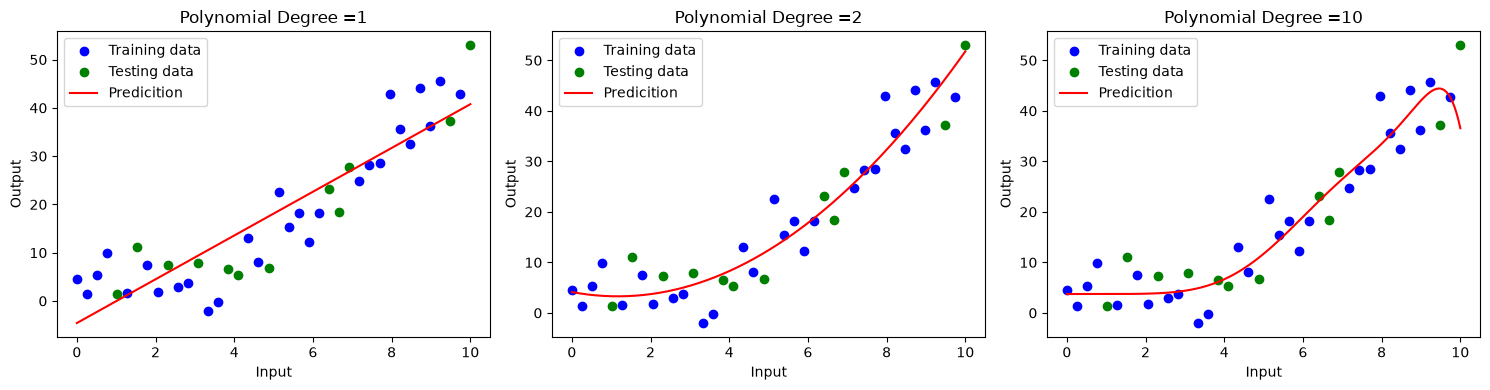

In [3]:
X_plot=np.linspace(0,10,200).reshape(-1,1)
plt.figure(figsize=(15,4))
for index, degree in enumerate(degrees):
    model=make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )

    model.fit(X_train,y_train)
    y_plot=model.predict(X_plot)

    plt.subplot(1,3,index+1)
    plt.scatter(X_train,y_train,color="blue",label="Training data")
    plt.scatter(X_test,y_test,color="green",label="Testing data")
    plt.plot(X_plot,y_plot,color="red",label="Predicition")

    plt.title(f"Polynomial Degree ={degree}")
    plt.xlabel("Input")
    plt.ylabel("Output")
    plt.legend()
plt.tight_layout()
plt.show()

### **Cross-Validation-Score**

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline



for degree in range(1, 11):
    model=make_pipeline(
        PolynomialFeatures(degree=degree,include_bias=False),
        LinearRegression()
    )

    scores=cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="neg_mean_squared_error"
        # scikit-learn returns the negative value of the Mean Squared Error(MSE)
        # so that higher (less negative) values represent better model performance
    )
    mean_mse = -scores.mean()
    print(f"Degree{degree}: CV MSE={mean_mse:.2f}")
   

Degree1: CV MSE=110.69
Degree2: CV MSE=44.22
Degree3: CV MSE=71.23
Degree4: CV MSE=82.46
Degree5: CV MSE=1346.32
Degree6: CV MSE=7930.95
Degree7: CV MSE=20375.98
Degree8: CV MSE=31567.34
Degree9: CV MSE=55109.01
Degree10: CV MSE=67544.63


### **Variance Threshold**

In [5]:
import pandas as pd
from sklearn.feature_selection import VarianceThreshold

X=pd.DataFrame({
    "constant_feature":[1,1,1,1,1],
    "almost_constant":[0,0,0,0,1],
    "useful_feature":[10,20,30,40,50]
})

selector = VarianceThreshold(threshold=0.0)
X_selected =selector.fit_transform(X)

selected_columns=X.columns[selector.get_support()]
print("Selected features:",list(selected_columns))


Selected features: ['almost_constant', 'useful_feature']


### **Corelation Among the Features**

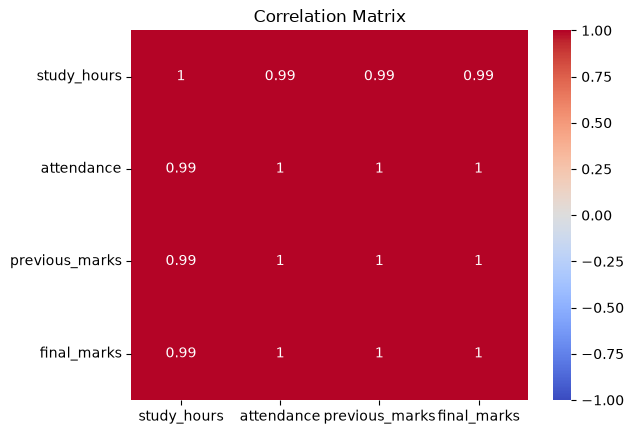

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.DataFrame({
    "study_hours":[1, 2, 3, 4, 5, 6],
    "attendance": [50, 55, 65, 70, 80, 90],
    "previous_marks": [35, 40, 50, 55, 65, 75],
    "final_marks": [38, 45, 52, 60, 70, 82]
})

correlation_matrix=data.corr(numeric_only=True)
# print(correlation_matrix)

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix")
plt.show()

### **Chi-Square for Breast-Cancer-Dataset**

In [7]:
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectKBest,chi2
from sklearn.preprocessing import MinMaxScaler

data=load_breast_cancer()
X=data.data
y=data.target

print("Number of features:",X.shape[1])


Number of features: 30


In [8]:
# Chi-square requires non-negative feature values
X_non_negative=MinMaxScaler().fit_transform(X)

selector = SelectKBest(score_func=chi2,k=5)
X_selected=selector.fit_transform(X_non_negative,y)

selected_features=data.feature_names[selector.get_support()]

print("Selected Features:")
print(selected_features)

Selected Features:
['mean concavity' 'mean concave points' 'worst perimeter' 'worst area'
 'worst concave points']


### **Chi-Square for Iris-Dataset**

In [9]:
from sklearn.datasets import load_iris
from sklearn.feature_selection import SelectKBest,chi2
from sklearn.preprocessing import MinMaxScaler

iris=load_iris()
X=iris.data
y=iris.target

print("Number of features:",X.shape[1])

Number of features: 4


In [10]:
# Select 3 best features
X_select=SelectKBest(chi2,k=3).fit_transform(X,y)
# X_select.shape
# X_select
X_select[:10]

array([[5.1, 1.4, 0.2],
       [4.9, 1.4, 0.2],
       [4.7, 1.3, 0.2],
       [4.6, 1.5, 0.2],
       [5. , 1.4, 0.2],
       [5.4, 1.7, 0.4],
       [4.6, 1.4, 0.3],
       [5. , 1.5, 0.2],
       [4.4, 1.4, 0.2],
       [4.9, 1.5, 0.1]])

### **Anova**

f_Classif applies the ANOVA F-test to each feature

In [13]:
from sklearn.datasets import load_iris
from sklearn.feature_selection import SelectKBest,f_classif

data=load_iris()
X=data.data
y=data.target

print("Number of features:",X.shape[1])

selector=SelectKBest(score_func=f_classif,k=2)
X_selected=selector.fit_transform(X,y)

import numpy as np
selected_features=np.array(data.feature_names)[selector.get_support()]

print("Selected features:",selected_features)

Number of features: 4
Selected features: ['petal length (cm)' 'petal width (cm)']


For regression, Scikit-learn provides f_regression.bold text

In [14]:
from sklearn.feature_selection import SelectKBest,f_regression

selector=SelectKBest(score_func=f_regression,k=3)
X_selected=selector.fit_transform(X,y)

import numpy as np
selected_features=np.array(data.feature_names)[selector.get_support()]

print("Selected features:",selected_features)

Selected features: ['sepal length (cm)' 'petal length (cm)' 'petal width (cm)']
